# ZeRO from scratch on 32 virtual GPUs

**What this notebook does:** it builds a 32-device "GPU cluster" out of CPU threads, trains a small
GPT on it, and implements **ZeRO stage 1, stage 2 and stage 3** by hand — real all-gathers, real
reduce-scatters, real sharded Adam — so we can watch memory and communication change as we move up
the stages.

Nothing here is mocked. The collectives move actual tensors, the optimizer actually updates only the
slice of the weights that a rank owns, and ZeRO-3 genuinely does not have the full weight matrix in
memory except for the microsecond in which a layer is computing.

### The one idea behind ZeRO

Data parallelism replicates. Every GPU holds a full copy of the parameters, a full copy of the
gradients, and a full copy of the optimizer state. That replication is **pure redundancy**: 32 GPUs
hold 32 identical copies of Adam's momentum buffers, and at any moment 31 of them are doing nothing
useful with their copy.

ZeRO's observation is that this state can be *partitioned* instead of *replicated*. Rank $r$ keeps
$1/N$ of it and, at the exact moment some other rank needs a piece, a collective fetches it. You pay
in communication and get back memory — near-linear memory reduction in the number of devices, with
**no change to the mathematics**. The loss curve is the same curve.

The three stages just answer "how much are we brave enough to partition?"

| | optimizer state | gradients | parameters | memory / GPU (mixed-prec Adam) |
|---|---|---|---|---|
| DDP | replicated | replicated | replicated | $16\Psi$ |
| **ZeRO-1** $P_{os}$ | **sharded** | replicated | replicated | $4\Psi + \frac{12\Psi}{N}$ |
| **ZeRO-2** $P_{os+g}$ | **sharded** | **sharded** | replicated | $2\Psi + \frac{14\Psi}{N}$ |
| **ZeRO-3** $P_{os+g+p}$ | **sharded** | **sharded** | **sharded** | $\frac{16\Psi}{N}$ |

We will measure every one of those numbers.

Throughout, the metric I lead with is **model state = params + gradients + optimizer** — the quantity
ZeRO actually addresses and the one the paper tabulates. Peak totals including activations are
reported too, with an explicit control in Part 7 for a confound that otherwise flatters ZeRO-3.

In [1]:
# Colab / fresh-clone bootstrap
try:
    import vgpu  # noqa
except ImportError:
    import subprocess, sys, os
    subprocess.run(["git", "clone", "-q",
                    "https://github.com/pyru/zero-vgpu-32.git"], check=False)
    sys.path.insert(0, "zero-vgpu-32")

import os, sys, math, time, json
import torch, numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
pd.set_option("display.width", 160)

from vgpu.fabric  import Fabric, PROFILES
from vgpu.memory  import MB, GB, fmt
from vgpu.model   import GPTConfig, build_specs, param_count, make_batch
from vgpu.zero    import ZeroEngine, STAGES
from vgpu.experiment import (run_stage, compare, weight_agreement,
                             analytic_memory, analytic_comm, final_params)
from vgpu import report

print("torch", torch.__version__, "| host CPUs:", os.cpu_count())

torch 2.11.0+cpu | host CPUs: 8


---
## Part 0 — Why 16 bytes per parameter

Before any code, the arithmetic that makes ZeRO necessary. Take mixed-precision training with Adam,
the standard recipe. For **every single parameter** $\psi$ you store:

| tensor | dtype | bytes |
|---|---|---|
| parameter (the fp16 copy used for fwd/bwd) | fp16 | 2 |
| gradient | fp16 | 2 |
| fp32 **master** copy of the parameter | fp32 | 4 |
| Adam momentum $m$ | fp32 | 4 |
| Adam variance $v$ | fp32 | 4 |
| | | **16 bytes** |

The three fp32 tensors exist because fp16 does not have enough mantissa to accumulate small updates —
`w += lr * small` silently rounds to `w`. So we keep a full-precision master weight and full-precision
moments, and that "optimizer state" alone is **12 of the 16 bytes: 75% of the footprint.**

That is the single most important number in this whole notebook. The weights you think of as "the
model" are 2 bytes out of 16. The optimizer is the elephant.

In [2]:
def state_breakdown(psi):
    return pd.DataFrame([
        ("fp16 parameters",  2, 2*psi),
        ("fp16 gradients",   2, 2*psi),
        ("fp32 master weights", 4, 4*psi),
        ("Adam m (fp32)",    4, 4*psi),
        ("Adam v (fp32)",    4, 4*psi),
    ], columns=["tensor", "bytes/param", "total bytes"]).assign(
        GB=lambda d: d["total bytes"]/1e9,
        share=lambda d: (d["total bytes"]/d["total bytes"].sum()).map("{:.0%}".format))

psi = 7.5e9  # the ZeRO paper's running example
df = state_breakdown(psi)
print(f"A {psi/1e9:.1f}B-parameter model, mixed precision + Adam:\n")
print(df[["tensor","bytes/param","GB","share"]].to_string(index=False))
print(f"\nTOTAL per GPU: {df['total bytes'].sum()/1e9:.0f} GB  "
      f"-> needs {math.ceil(df['total bytes'].sum()/1e9/80)} x 80GB H100 just to HOLD it,"
      f"\n   and data parallelism does not help at all: every GPU stores the same 120 GB.")

A 7.5B-parameter model, mixed precision + Adam:

             tensor  bytes/param   GB share
    fp16 parameters            2 15.0   12%
     fp16 gradients            2 15.0   12%
fp32 master weights            4 30.0   25%
      Adam m (fp32)            4 30.0   25%
      Adam v (fp32)            4 30.0   25%

TOTAL per GPU: 120 GB  -> needs 2 x 80GB H100 just to HOLD it,
   and data parallelism does not help at all: every GPU stores the same 120 GB.


---
## Part 1 — Building 32 virtual GPUs

A GPU cluster, from the training loop's point of view, is really just three things:

1. **N independent execution contexts** that run the same program on different data,
2. **private memory** per context,
3. **collective communication primitives** that move tensors between them.

I can get all three from CPU threads. Each thread is a rank; each rank gets its own memory ledger;
the collectives are implemented with a `threading.Barrier` plus a shared staging area. Because torch
ops release the GIL, the 32 threads genuinely interleave on the host's cores.

**What is simulated and what is real** — I want to be precise about this:

* *Real:* the tensors, the maths, the partitioning, the sequence of collectives, the number of bytes
  each collective puts on the wire, the memory each rank holds.
* *Modelled:* the **time** a collective takes. Threads share RAM, so a "transfer" is a memcpy and
  would be unrealistically fast. I charge each collective
  $t = \text{hops}\times\text{latency} + \text{wire bytes} / \text{bandwidth}$
  using published NVLink/InfiniBand numbers, with the standard **ring** cost model:

$$\text{all\_gather} = \text{reduce\_scatter} = \frac{N-1}{N}S, \qquad
  \text{all\_reduce} = 2\frac{N-1}{N}S$$

That $\frac{N-1}{N}$ is why an all-reduce costs $2\Psi$ and not $N\Psi$: a ring all-reduce is just a
reduce-scatter followed by an all-gather, and each rank only ever sends $N-1$ of the $N$ chunks.

Charging latency *per hop* rather than per call matters: a ring collective is $N-1$
sequential steps, so on a slow link with many ranks the latency term can dominate the
bandwidth term. (Real NCCL switches to tree algorithms exactly when that happens; I model
the ring only, and say so.)

In [3]:
fabric = Fabric(world_size=32, interconnect="nvlink4")
print(fabric)
print("first four devices:", fabric.gpus[:4], "...\n")

# a live demonstration of each collective on the 32-device fabric
def demo(rank, fab):
    x = torch.full((8,), float(rank))               # rank r holds [r,r,...,r]
    ar = fab.all_reduce(rank, x)                    # -> sum over ranks = 496
    rs = fab.reduce_scatter(rank, torch.arange(32.) * (rank + 1))
    ag = fab.all_gather(rank, torch.tensor([float(rank)]))
    return ar[0].item(), rs.item(), ag.numel()

out = fabric.run(demo)
print(f"all_reduce      : every rank sees sum(0..31)      = {out[0][0]:.0f}   "
      f"(expected {sum(range(32))})")
print(f"reduce_scatter  : rank 5 keeps only element 5     = {out[5][1]:.0f}   "
      f"(expected {5*sum(range(1,33)):.0f})")
print(f"all_gather      : 1 element in -> {out[0][2]} elements out (the whole cluster's data)")
print(f"\nbytes charged to rank 0: {fmt(fabric.gpu(0).comm.total_bytes)}"
      f"  in {fabric.gpu(0).comm.total_calls} calls")

<Fabric world_size=32 link=NVLink-4 / NVSwitch (intra-node) 300.0 GB/s>
first four devices: [<vGPU:00 mem_peak=0.0MB>, <vGPU:01 mem_peak=0.0MB>, <vGPU:02 mem_peak=0.0MB>, <vGPU:03 mem_peak=0.0MB>] ...

all_reduce      : every rank sees sum(0..31)      = 496   (expected 496)
reduce_scatter  : rank 5 keeps only element 5     = 2640   (expected 2640)
all_gather      : 1 element in -> 32 elements out (the whole cluster's data)

bytes charged to rank 0: 0.3 KB  in 3 calls


In [4]:
# the interconnect matters enormously -- same bytes, very different time
S = 1e9  # move 1 GB
rows = []
for k, p in PROFILES.items():
    for N in (8, 32, 256):
        wire = 2*(N-1)/N*S
        rows.append(dict(link=p.name, N=N, GBps=p.bandwidth_GBps,
                         all_reduce_1GB_ms=1e3*(p.latency_us*1e-6 + wire/(p.bandwidth_GBps*1e9))))
print(pd.DataFrame(rows).pivot(index="link", columns="N",
                               values="all_reduce_1GB_ms").round(1).to_string())
print("\n(ms to all-reduce a 1 GB gradient buffer. The (N-1)/N factor saturates fast --")
print(" going from 8 to 256 GPUs barely changes the cost. Bandwidth is what matters.)")

N                                   8      32     256
link                                                 
100 Gb Ethernet                   140.0  155.0  159.4
InfiniBand NDR 400 Gb/s            35.0   38.8   39.8
NVLink-4 / NVSwitch (intra-node)    5.8    6.5    6.6
PCIe 4.0 x16                       70.0   77.5   79.7

(ms to all-reduce a 1 GB gradient buffer. The (N-1)/N factor saturates fast --
 going from 8 to 256 GPUs barely changes the cost. Bandwidth is what matters.)


---
## Part 2 — The demo model

A small pre-LayerNorm GPT: token + position embeddings, 4 transformer blocks (causal self-attention +
MLP), a final norm and an LM head. ~0.93M parameters.

The one unusual thing about it: **it is not an `nn.Module` with `.parameters()`.** It is a list of
`LayerSpec`s — `(name, [(param_name, shape), ...], fn(x, P))` — where `P` is a plain dict of tensors
handed in from outside.

That indirection is not stylistic, it is *what makes ZeRO-3 possible*. If weights are permanently
bolted onto a module, you cannot make them not exist. By passing them in per call, ZeRO-3 can
materialise a layer's weights one instruction before the layer runs and drop them one instruction
after.

Each `LayerSpec` is also exactly one **ZeRO parameter group** — the granularity at which we shard,
gather and reduce. Real DeepSpeed/FSDP use the same idea, calling them *buckets* or *FlatParameters*.

In [5]:
cfg = GPTConfig(vocab_size=512, block_size=32, n_layer=4, n_head=4, d_model=128)
specs = build_specs(cfg)
PSI = param_count(cfg)

print(pd.DataFrame([
    dict(group=s.name, tensors=len(s.params), params=s.numel,
         fp32_MB=round(s.numel*4/MB, 3),
         shard_on_32=s.numel//32) for s in specs]).to_string(index=False))
print(f"\npsi = {PSI:,} parameters = {PSI*4/MB:.2f} MB in fp32")
print(f"full training state (fp32 params+grads+Adam m,v = 16 B/param): {PSI*16/MB:.2f} MB per GPU")

 group  tensors  params  fp32_MB  shard_on_32
 embed        2   69632    0.266         2176
block0       12  198272    0.756         6196
block1       12  198272    0.756         6196
block2       12  198272    0.756         6196
block3       12  198272    0.756         6196
  head        3   65792    0.251         2056

psi = 928,512 parameters = 3.54 MB in fp32
full training state (fp32 params+grads+Adam m,v = 16 B/param): 14.17 MB per GPU


---
## Part 3 — The reference run, and what DDP actually buys you

First a single device with the whole global batch of 32 sequences. This is our **ground truth**:
every distributed configuration below must reproduce its loss curve exactly, otherwise the
"distribution" changed the maths and is simply wrong.

Then plain DDP on 32 ranks. It is worth being very clear about what DDP does and does not fix:

* **It does fix activations.** Each rank runs batch 1 instead of batch 32, so activation memory
  drops ~32×. That is a genuine and large win.
* **It does nothing for model state.** Parameters, gradients and Adam moments are *replicated* — all
  32 ranks carry the identical 14 MB. Scaling to 1000 GPUs does not shrink it by one byte.

DDP's one collective is an **all-reduce** of the gradients: $2\frac{N-1}{N}\Psi$ bytes.

In [6]:
STEPS, GLOBAL_BATCH = 8, 32
results = {}
for stage in ["baseline", "ddp", "zero1", "zero2", "zero3"]:
    t0 = time.time()
    results[stage] = run_stage(stage, cfg, world_size=32, steps=STEPS,
                               global_batch=GLOBAL_BATCH)
    r = results[stage]
    print(f"{report.LABEL[stage]:24s} model state {fmt(r['peak_model_state']):>9s}   "
          f"peak {fmt(r['peak_total']):>9s}   comm {r['comm_ratio_psi']:.3f} psi   "
          f"loss {r['losses'][0]:.4f} -> {r['losses'][-1]:.4f}   [{time.time()-t0:.1f}s]")

1 GPU (no DP)            model state  14.17 MB   peak  49.43 MB   comm 0.000 psi   loss 6.2725 -> 4.9970   [2.4s]


DDP (no ZeRO)            model state  14.17 MB   peak  15.39 MB   comm 1.938 psi   loss 6.2725 -> 4.9970   [12.9s]


ZeRO-1  $P_{os}$         model state   7.31 MB   peak   8.53 MB   comm 1.938 psi   loss 6.2725 -> 4.9970   [17.1s]


ZeRO-2  $P_{os+g}$       model state   4.60 MB   peak   5.82 MB   comm 1.938 psi   loss 6.2725 -> 4.9970   [12.9s]


ZeRO-3  $P_{os+g+p}$     model state   1.17 MB   peak   2.19 MB   comm 2.906 psi   loss 6.2725 -> 4.9970   [17.4s]


In [7]:
b, d = results["baseline"], results["ddp"]
print("                         1 GPU (batch 32)      DDP x32 (batch 1/rank)")
for c, nm in [("params","parameters"), ("grads","gradients"), ("optimizer","Adam m,v"),
              ("activations","activations")]:
    print(f"  {nm:<14s}  {fmt(b['peak_by_cat'][c]):>14s} {fmt(d['peak_by_cat'][c]):>22s}")
print(f"  {'PEAK':<14s}  {fmt(b['peak_total']):>14s} {fmt(d['peak_total']):>22s}")
print(f"\nactivations shrank {b['peak_by_cat']['activations']/d['peak_by_cat']['activations']:.1f}x "
      f"(that's data parallelism working)")
print(f"model state shrank {b['peak_model_state']/d['peak_model_state']:.2f}x "
      f"(that's data parallelism doing nothing -- and model state is "
      f"{100*d['peak_model_state']/d['peak_total']:.0f}% of DDP's footprint)")

                         1 GPU (batch 32)      DDP x32 (batch 1/rank)
  parameters             3.54 MB                3.54 MB
  gradients              3.54 MB                3.54 MB
  Adam m,v               7.08 MB                7.08 MB
  activations           35.26 MB                1.22 MB
  PEAK                  49.43 MB               15.39 MB

activations shrank 28.8x (that's data parallelism working)
model state shrank 1.00x (that's data parallelism doing nothing -- and model state is 92% of DDP's footprint)


---
## Part 4 — ZeRO-1 ($P_{os}$): shard the optimizer

**The move.** Rank $r$ keeps Adam's $m$ and $v$ only for its $1/N$ slice of the weights. Nothing else
changes shape.

**Why it is safe.** Adam is *element-wise*. The update for weight $i$ depends on $g_i, m_i, v_i$ and
nothing else. So partitioning the optimizer across ranks is not an approximation — it is just deciding
who does which subset of an embarrassingly parallel computation.

**What it costs.** Each rank now only updates $1/N$ of the weights, so after the step the ranks
disagree about the other $(N-1)/N$. One **all-gather** of the updated parameters fixes that.

**The accounting trick:** instead of DDP's `all_reduce` ($2\frac{N-1}{N}\Psi$), ZeRO-1 does
`reduce_scatter` + `all_gather` = $\frac{N-1}{N}\Psi + \frac{N-1}{N}\Psi$ — **exactly the same total
volume.** A ring all-reduce *is* those two operations; ZeRO-1 just declines to reassemble the
gradient in the middle. **ZeRO-1 is free.** Same maths, same comms, 12 bytes/param of savings.

That last sentence is the reason ZeRO-1 should essentially always be on.

In [8]:
z1 = results["zero1"]
print("ZeRO-1 vs DDP, per GPU:")
for c in ["params", "grads", "optimizer"]:
    print(f"  {c:<10s} {fmt(d['peak_by_cat'][c]):>10s} -> {fmt(z1['peak_by_cat'][c]):>10s}"
          f"   ({d['peak_by_cat'][c]/max(z1['peak_by_cat'][c],1):.1f}x)")
print(f"  {'PEAK':<10s} {fmt(d['peak_total']):>10s} -> {fmt(z1['peak_total']):>10s}")
print("\ncollectives per step (MB on the wire, per rank):")
print("  DDP   :", {k: round(v/MB,3) for k,v in d['comm_by_op'].items() if v})
print("  ZeRO-1:", {k: round(v/MB,3) for k,v in z1['comm_by_op'].items() if v})
print(f"\n  total  DDP {d['comm_ratio_psi']:.3f} psi   vs   ZeRO-1 {z1['comm_ratio_psi']:.3f} psi"
      f"   <-- identical. ZeRO-1 costs nothing.")

ZeRO-1 vs DDP, per GPU:
  params        3.54 MB ->    3.54 MB   (1.0x)
  grads         3.54 MB ->    3.54 MB   (1.0x)
  optimizer     7.08 MB ->   226.7 KB   (32.0x)
  PEAK         15.39 MB ->    8.53 MB

collectives per step (MB on the wire, per rank):
  DDP   : {'all_reduce': 6.863}
  ZeRO-1: {'reduce_scatter': 3.431, 'all_gather': 3.431}

  total  DDP 1.938 psi   vs   ZeRO-1 1.938 psi   <-- identical. ZeRO-1 costs nothing.


---
## Part 5 — ZeRO-2 ($P_{os+g}$): shard the gradients too

**The move.** If rank $r$ is only ever going to *use* the gradient for its own slice (that is all
ZeRO-1 left it doing), why does it store the whole gradient buffer?

**The subtlety, and the thing I think is the real insight of stage 2.** ZeRO-1 already issues a
`reduce_scatter` — but it issues it *after the whole backward pass has finished*, by which time the
full gradient tensor has already been materialised. Stage 2 changes **when**, not **what**:

> reduce-scatter each layer's gradient **the instant that layer's backward finishes**, keep your
> $1/N$, and free the full buffer before the next layer's backward even starts.

So the comm volume is unchanged ($2\Psi$, same as DDP) but the peak gradient memory falls from
"the whole model" to "one layer + my shards". In this implementation that is literally a
`register_post_accumulate_grad_hook` per parameter group.

This also explains why real ZeRO-2 has a `reduce_bucket_size` knob: the transient is one *bucket*,
so the bucket size is a direct memory/efficiency dial — big buckets communicate more efficiently,
small buckets hold less memory.

**And it explains a peak you will see below that is not $\Psi/N$.** ZeRO-2's measured gradient peak is
~855 KB, not the ideal 113 KB, because at the moment the largest block's gradient is complete but not
yet scattered, that full buffer is live. That transient is real, it exists in DeepSpeed too, and I
would rather show it than quote the idealised formula.

In [9]:
z2 = results["zero2"]
print("gradient memory, peak per GPU:")
for k, r in [("DDP", d), ("ZeRO-1", z1), ("ZeRO-2", z2)]:
    print(f"  {k:<8s} {fmt(r['peak_by_cat']['grads']):>10s}")
ideal = PSI*4/32
print(f"\n  ideal psi/N   {fmt(ideal):>10s}   <- ZeRO-2 does not reach this...")
big = max(s.numel for s in specs)*4
print(f"  largest group {fmt(big):>10s}   <- ...because of this transient: the biggest single")
print( "                              layer's full gradient is live between 'backward of")
print( "                              that layer done' and 'reduce_scatter done'.")
print(f"\n  ZeRO-2 comm {z2['comm_ratio_psi']:.3f} psi -- still identical to DDP. Stage 2 is also ~free.")

gradient memory, peak per GPU:
  DDP         3.54 MB
  ZeRO-1      3.54 MB
  ZeRO-2     855.1 KB

  ideal psi/N     113.3 KB   <- ZeRO-2 does not reach this...
  largest group   774.5 KB   <- ...because of this transient: the biggest single
                              layer's full gradient is live between 'backward of
                              that layer done' and 'reduce_scatter done'.

  ZeRO-2 comm 1.938 psi -- still identical to DDP. Stage 2 is also ~free.


---
## Part 6 — ZeRO-3 ($P_{os+g+p}$): shard the parameters

This is the one that actually changes the forward pass, and the one worth understanding properly.

**The move.** Rank $r$ stores only $1/N$ of every weight matrix. But you cannot multiply by a
fraction of a weight matrix — so immediately before a layer runs, the cluster **all-gathers** that
layer's weights; the layer computes; the gathered copy is **freed**.

The whole implementation is one autograd Function:

```python
forward:   full = all_gather(shard)      # materialise layer L's weights
           out  = layer(x, full)
           del full                      # ...and they are gone again

backward:  full  = all_gather(shard)     # re-materialise (we threw them away!)
           grads = local_backward(...)   # gradient w.r.t. the FULL weight
           gshard = reduce_scatter(grads)# keep only my 1/N
```

**Three consequences fall straight out of those six lines:**

1. **Peak parameter memory is one layer, not the model.** This is why ZeRO-3 can train a model far
   larger than one GPU's memory — you only ever need to fit the biggest single layer.
2. **Comm volume goes from $2\Psi$ to $3\Psi$.** Two all-gathers (forward + backward) and one
   reduce-scatter. That 1.5× is ZeRO-3's entire price, and it is why stages 1 and 2 are free but
   stage 3 is a decision.
3. **Backward must recompute the layer**, because the activations' backward needs weights we deleted.
   That is activation checkpointing, arriving for free as a side effect — which is why the
   activation column also drops. I am flagging this explicitly rather than quietly banking the win:
   part of ZeRO-3's measured activation saving here is recompute, not sharding.

The `keep_gathered=True` flag holds the gathered weights until backward instead: no second
all-gather ($3\Psi \to 2\Psi$), but the weights stay resident. It is a clean memory-vs-bandwidth
dial, and we measure both ends of it below.

In [10]:
z3 = results["zero3"]
print("ZeRO-3, per GPU:")
for c in ["params", "grads", "optimizer", "activations"]:
    print(f"  {c:<12s} DDP {fmt(d['peak_by_cat'][c]):>10s}  ->  ZeRO-3 {fmt(z3['peak_by_cat'][c]):>10s}"
          f"   ({d['peak_by_cat'][c]/max(z3['peak_by_cat'][c],1):5.1f}x)")
print(f"\n  resident params (steady state) : {fmt(z3['engines'][0].mem.cur['params'])}"
      f"   = psi/N = {fmt(PSI*4/32)}")
print(f"  peak incl. gathered layer      : {fmt(z3['peak_by_cat']['params']+z3['peak_by_cat']['comm'])}")
print(f"\n  comm: {z3['comm_ratio_psi']:.3f} psi  vs  DDP {d['comm_ratio_psi']:.3f} psi"
      f"   ->  {z3['comm_ratio_psi']/d['comm_ratio_psi']:.2f}x more traffic")
print("  breakdown:", {k: round(v/MB,3) for k,v in z3['comm_by_op'].items() if v},
      "  (all_gather is 2x reduce_scatter: forward + backward)")

ZeRO-3, per GPU:
  params       DDP    3.54 MB  ->  ZeRO-3   113.3 KB   ( 32.0x)
  grads        DDP    3.54 MB  ->  ZeRO-3   855.1 KB   (  4.2x)
  optimizer    DDP    7.08 MB  ->  ZeRO-3   226.7 KB   ( 32.0x)
  activations  DDP    1.22 MB  ->  ZeRO-3   272.0 KB   (  4.6x)

  resident params (steady state) : 113.3 KB   = psi/N = 113.3 KB
  peak incl. gathered layer      : 887.8 KB

  comm: 2.906 psi  vs  DDP 1.938 psi   ->  1.50x more traffic
  breakdown: {'all_gather': 6.863, 'reduce_scatter': 3.431}   (all_gather is 2x reduce_scatter: forward + backward)


In [11]:
# the memory/bandwidth dial: keep the gathered weights instead of re-gathering
kg = run_stage("zero3", cfg, world_size=32, steps=4, global_batch=32, keep_gathered=True)
rg = run_stage("zero3", cfg, world_size=32, steps=4, global_batch=32, keep_gathered=False)
print(f"{'ZeRO-3 variant':<34s}{'peak/GPU':>12s}{'comm/step':>14s}")
print(f"{'re-gather in backward (default)':<34s}{fmt(rg['peak_total']):>12s}"
      f"{rg['comm_ratio_psi']:>11.2f} psi")
print(f"{'keep gathered weights alive':<34s}{fmt(kg['peak_total']):>12s}"
      f"{kg['comm_ratio_psi']:>11.2f} psi")
print("\n-> exactly the trade the paper describes: you can buy back the extra psi of")
print("   bandwidth by paying for it in resident memory.")

ZeRO-3 variant                        peak/GPU     comm/step
re-gather in backward (default)        2.13 MB       2.91 psi
keep gathered weights alive            4.59 MB       1.94 psi

-> exactly the trade the paper describes: you can buy back the extra psi of
   bandwidth by paying for it in resident memory.


---
## Part 7 — Controlling for the activation confound

Before quoting a headline number I have to deal with something that would otherwise flatter ZeRO-3.

ZeRO-3 recomputes each layer in backward (it deleted the weights it would have needed). The other
stages do not. So ZeRO-3 gets **layer-wise activation checkpointing for free**, and activations are
the largest non-model-state term. A naive "peak memory" comparison would be partly measuring
checkpointing rather than sharding.

In the paper this distinction is explicit: $P_{os+g+p}$ partitions **model state only**; partitioned
activation checkpointing is a separate mechanism (ZeRO-R / $P_a$).

So here is the control: re-run every stage with `checkpoint=True`, which makes DDP, ZeRO-1 and ZeRO-2
recompute exactly the way ZeRO-3 does. Identical activation footing, so whatever difference survives
is the model-state sharding and nothing else.

In [12]:
fair = {s: run_stage(s, cfg, world_size=32, steps=4, global_batch=32, checkpoint=True)
        for s in ["ddp", "zero1", "zero2", "zero3"]}
print(f"{'':24s}{'activations':>13s}{'model state':>13s}{'peak total':>13s}")
for s, r in fair.items():
    print(f"{report.LABEL[s]:24s}{fmt(r['peak_by_cat']['activations']):>13s}"
          f"{fmt(r['peak_model_state']):>13s}{fmt(r['peak_total']):>13s}")
print(f"\nactivations now identical across all four stages.")
print(f"peak DDP -> ZeRO-3 : {fair['ddp']['peak_total']/fair['zero3']['peak_total']:.1f}x"
      f"   (not an artifact of checkpointing)")
print(f"model state        : {fair['ddp']['peak_model_state']/fair['zero3']['peak_model_state']:.1f}x")
print(f"losses still identical: {[round(fair[s]['losses'][-1], 6) for s in fair]}")

                          activations  model state   peak total
DDP (no ZeRO)                208.0 KB     14.17 MB     14.92 MB
ZeRO-1  $P_{os}$             208.0 KB      7.31 MB      7.51 MB
ZeRO-2  $P_{os+g}$           208.0 KB      4.60 MB      4.80 MB
ZeRO-3  $P_{os+g+p}$         208.0 KB      1.17 MB      2.13 MB

activations now identical across all four stages.
peak DDP -> ZeRO-3 : 7.0x   (not an artifact of checkpointing)
model state        : 12.1x
losses still identical: [5.685081, 5.685081, 5.685081, 5.685081]


---
## Part 8 — Everything side by side

In [13]:
tbl = report.table_summary(results)
print(tbl.to_string())
tbl

                       N  params (MB)  grads (MB)  optim (MB)  activations (MB)  model state (MB)  PEAK all (MB)  comm/step (MB)  comm (x psi)  final loss
stage                                                                                                                                                     
1 GPU (no DP)          1       3.5420      3.5420      7.0840           35.2578           14.1680        49.4258          0.0000        0.0000       4.997
DDP (no ZeRO)         32       3.5420      3.5420      7.0840            1.2229           14.1680        15.3909          6.8626        1.9375       4.997
ZeRO-1  $P_{os}$      32       3.5420      3.5420      0.2214            1.2229            7.3054         8.5283          6.8626        1.9375       4.997
ZeRO-2  $P_{os+g}$    32       3.5420      0.8351      0.2214            1.2229            4.5985         5.8214          6.8626        1.9375       4.997
ZeRO-3  $P_{os+g+p}$  32       0.1107      0.8351      0.2214         

,N,params (MB),grads (MB),optim (MB),activations (MB),model state (MB),PEAK all (MB),comm/step (MB),comm (x psi),final loss
stage,,,,,,,,,,
1 GPU (no DP),1,3.5420,3.5420,7.0840,35.2578,14.1680,49.4258,0.0000,0.0000,4.997
DDP (no ZeRO),32,3.5420,3.5420,7.0840,1.2229,14.1680,15.3909,6.8626,1.9375,4.997
ZeRO-1 $P_{os}$,32,3.5420,3.5420,0.2214,1.2229,7.3054,8.5283,6.8626,1.9375,4.997
ZeRO-2 $P_{os+g}$,32,3.5420,0.8351,0.2214,1.2229,4.5985,5.8214,6.8626,1.9375,4.997
ZeRO-3 $P_{os+g+p}$,32,0.1107,0.8351,0.2214,0.2656,1.1672,2.1891,10.2939,2.9062,4.997


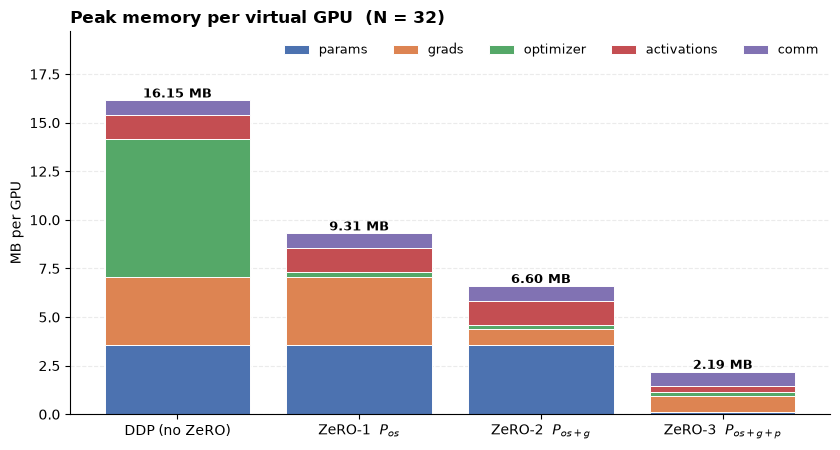

In [14]:
fig = report.fig_memory_breakdown(results); plt.show()

Read that chart left to right and you can see each stage delete exactly one block:

* **ZeRO-1** deletes the green *optimizer* block — the biggest single win, and it is free.
* **ZeRO-2** deletes the orange *gradient* block — also free.
* **ZeRO-3** deletes the blue *parameter* block — the only one you pay for.

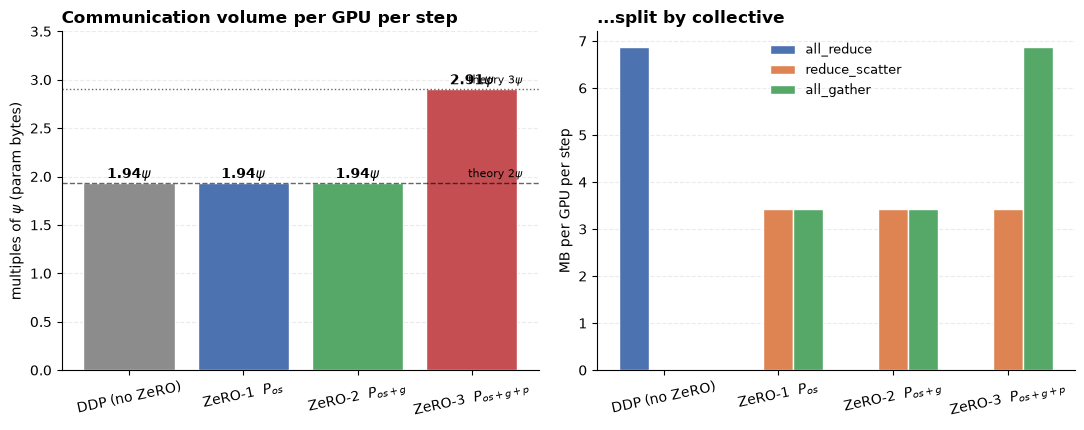

In [15]:
fig = report.fig_comm(results); plt.show()

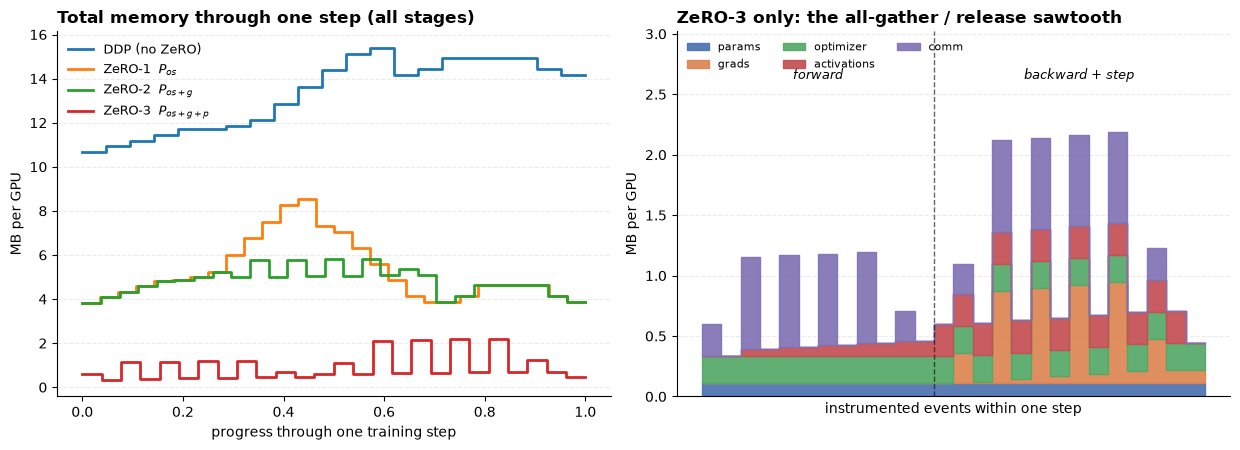

In [16]:
fig = report.fig_timeline(results); plt.show()

The left panel is the clearest picture of the three stages I can produce:

* **DDP** climbs as each layer's gradient appears and then just *stays there* — nothing is ever
  released.
* **ZeRO-1** climbs the same way, then drops off a cliff: the reduce-scatter at the end of backward.
  Same peak shape as DDP, same comms, but afterwards it is holding a shard.
* **ZeRO-2** never climbs — the sawtooth is each layer's gradient being scattered and freed as soon
  as it is ready.
* **ZeRO-3** is flat and low the whole way through, with the gather/release teeth visible.

The right panel is the ZeRO-3 sawtooth on its own scale. Each tooth in the forward half is one layer
being materialised and destroyed; the taller teeth in the backward half are the re-gather plus that
layer's full gradient, just before the reduce-scatter takes it away.

---
## Part 9 — Does it still compute the right thing?

This is the part that matters most. ZeRO's whole claim is that it is a **pure memory optimization** —
it changes where bytes live, never what is computed. If my implementation is right, all five
configurations must produce the same loss curve and the same final weights, to within fp32 rounding.

Every run uses the same seed, the same initial weights and the same data. The global batch is split
across ranks and the loss is normalised by the *global* token count, so summing gradients with a
reduce reproduces single-device training exactly.

In [17]:
print("loss agreement with the single-GPU reference:\n")
print(pd.DataFrame(compare(results)).to_string(index=False))
print("\nfinal-weight agreement (all 928,512 weights, ZeRO-3's reassembled from its 32 shards):\n")
print(pd.DataFrame(weight_agreement(results)).to_string(index=False))

# the sharper test: how do the ZeRO stages compare to EACH OTHER?
W = {s: final_params(results[s]) for s in ["baseline","ddp","zero1","zero2","zero3"]}
ks = ["ddp", "zero1", "zero2", "zero3"]
print("\npairwise max|dW| between distributed stages:\n")
for i in range(len(ks)):
    for j in range(i+1, len(ks)):
        print(f"  {ks[i]:6s} vs {ks[j]:6s}: {float((W[ks[i]]-W[ks[j]]).abs().max()):.3e}")
print(f"  {'any':6s} vs {'1 GPU':6s}: {float((W['zero3']-W['baseline']).abs().max()):.3e}")

loss agreement with the single-GPU reference:

   stage  final_loss  max_abs_dev
baseline    4.997026     0.000000
     ddp    4.997034     0.000014
   zero1    4.997034     0.000014
   zero2    4.997034     0.000014
   zero3    4.997034     0.000014

final-weight agreement (all 928,512 weights, ZeRO-3's reassembled from its 32 shards):

   stage  max_abs_weight_diff      rel
baseline             0.000000 0.000000
     ddp             0.000089 0.000087
   zero1             0.000089 0.000087
   zero2             0.000089 0.000087
   zero3             0.000089 0.000087

pairwise max|dW| between distributed stages:

  ddp    vs zero1 : 1.482e-05
  ddp    vs zero2 : 1.482e-05
  ddp    vs zero3 : 1.482e-05
  zero1  vs zero2 : 0.000e+00
  zero1  vs zero3 : 0.000e+00
  zero2  vs zero3 : 0.000e+00
  any    vs 1 GPU : 8.909e-05


That table is a sharper result than I expected, and it is worth reading carefully.

**The three ZeRO stages are bit-identical to each other** -- not approximately, *exactly* -- because
all three reduce gradients with the same `reduce_scatter` and therefore sum the ranks' contributions
in the same order. DDP differs in the last few ulps only because a ring `all_reduce` associates the
sum differently. The single-GPU run differs because it sums 32 microbatches as one batch rather than
as 32 partial sums.

So the *only* differences anywhere in this experiment are floating-point summation order. That is
about as strong a statement of "ZeRO does not change the maths" as one can make.

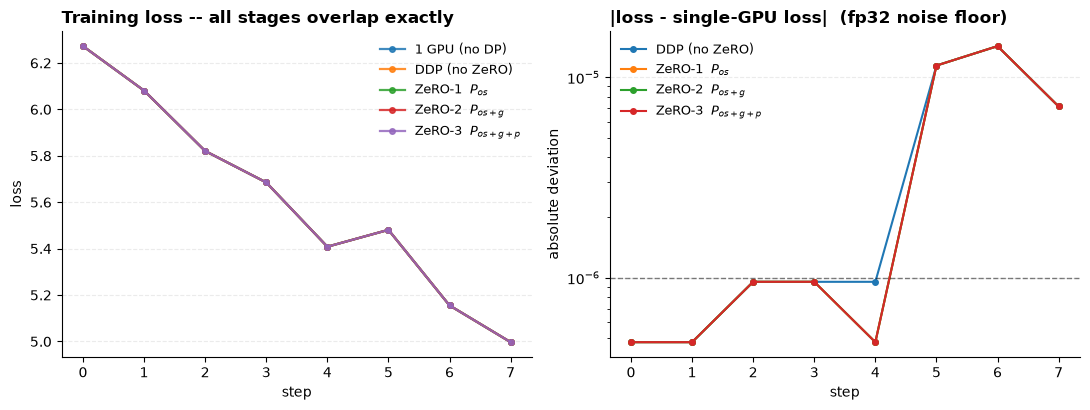

In [18]:
fig = report.fig_losses(results); plt.show()

---
## Part 10 — Scaling: memory vs. number of GPUs

The claim is *near-linear* memory reduction in $N$. Let's actually measure it by rerunning every
stage on 1, 2, 4, 8, 16 and 32 virtual GPUs.

The prediction: DDP is a flat line (data parallelism never reduces model state), while the ZeRO
curves fall towards their asymptotes $4\Psi$, $2\Psi$ and $0$.

In [19]:
sweep = {}
for n in [1, 2, 4, 8, 16, 32]:
    sweep[n] = {s: run_stage(s, cfg, world_size=n, steps=2, global_batch=32)
                for s in ["ddp", "zero1", "zero2", "zero3"]}
    ms = {s: (sweep[n][s]["peak_by_cat"]["params"] + sweep[n][s]["peak_by_cat"]["grads"]
              + sweep[n][s]["peak_by_cat"]["optimizer"])/MB for s in sweep[n]}
    print(f"  N={n:3d}   " + "   ".join(f"{k}={v:6.2f} MB" for k, v in ms.items()))

  N=  1   ddp= 14.17 MB   zero1= 14.17 MB   zero2= 14.17 MB   zero3= 14.17 MB


  N=  2   ddp= 14.17 MB   zero1= 10.63 MB   zero2=  9.10 MB   zero3=  7.33 MB


  N=  4   ddp= 14.17 MB   zero1=  8.85 MB   zero2=  6.70 MB   zero3=  4.04 MB


  N=  8   ddp= 14.17 MB   zero1=  7.97 MB   zero2=  5.50 MB   zero3=  2.40 MB


  N= 16   ddp= 14.17 MB   zero1=  7.53 MB   zero2=  4.90 MB   zero3=  1.58 MB


  N= 32   ddp= 14.17 MB   zero1=  7.31 MB   zero2=  4.60 MB   zero3=  1.17 MB


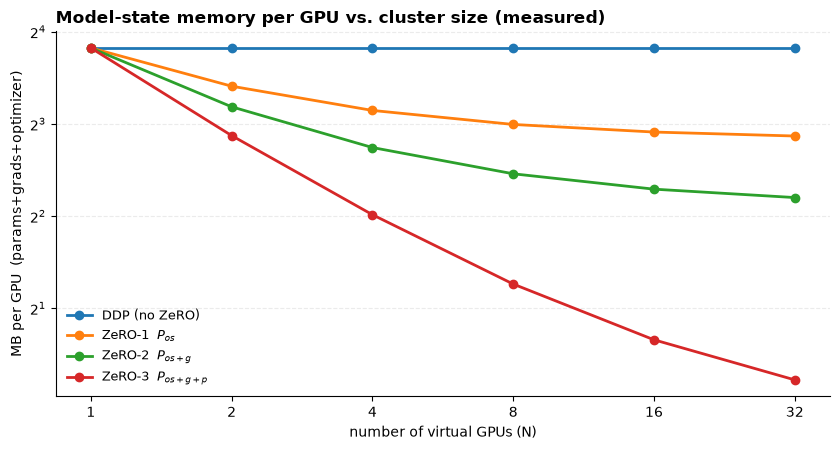

In [20]:
fig = report.fig_scaling(sweep); plt.show()

In [21]:
# measured vs the closed-form fp32 model (params 4B + grads 4B + Adam m,v 8B = 16B/param)
rows = []
for n in sorted(sweep):
    a = analytic_memory(PSI, n, precision="fp32")
    for s, key in [("ddp","DDP (no ZeRO)"), ("zero1","ZeRO-1 (Pos)"),
                   ("zero2","ZeRO-2 (Pos+g)"), ("zero3","ZeRO-3 (Pos+g+p)")]:
        m = sweep[n][s]
        rows.append(dict(N=n, stage=key,
                         measured_MB=(m["peak_by_cat"]["params"]+m["peak_by_cat"]["grads"]
                                      +m["peak_by_cat"]["optimizer"])/MB,
                         predicted_MB=a[key]/MB))
sw = pd.DataFrame(rows)
sw["ratio"] = (sw.measured_MB/sw.predicted_MB).round(2)
print(sw.pivot(index="N", columns="stage", values=["measured_MB","predicted_MB"]).round(2).to_string())
print("\nDDP and ZeRO-1 track the formula almost exactly. ZeRO-2/3 sit above it at large N")
print("for the reason from Part 5: the closed form ignores the one-bucket transient, which")
print("stops shrinking once psi/N gets smaller than a single layer.")

        measured_MB                                               predicted_MB                                             
stage DDP (no ZeRO) ZeRO-1 (Pos) ZeRO-2 (Pos+g) ZeRO-3 (Pos+g+p) DDP (no ZeRO) ZeRO-1 (Pos) ZeRO-2 (Pos+g) ZeRO-3 (Pos+g+p)
N                                                                                                                          
1             14.17        14.17          14.17            14.17         14.17        14.17          14.17            14.17
2             14.17        10.63           9.10             7.33         14.17        10.63           8.85             7.08
4             14.17         8.85           6.70             4.04         14.17         8.85           6.20             3.54
8             14.17         7.97           5.50             2.40         14.17         7.97           4.87             1.77
16            14.17         7.53           4.90             1.58         14.17         7.53           4.21             0.89
32      

---
## Part 11 — Extrapolating to a real model

Our TinyGPT is 0.93M parameters; the ratios are the point, not the absolute numbers. The closed-form
model lets us ask the question people actually care about: *what could I train on N GPUs?*

Below I reproduce **Table 1 of the ZeRO paper** ($\Psi = 7.5$B, $N_d = 64$, mixed-precision Adam).
If my understanding of the accounting is right, these should come out at 120 / 31.4 / 16.6 / 1.9 GB.

In [22]:
a = analytic_memory(7.5e9, 64, precision="mixed")
paper = {"DDP (no ZeRO)": 120.0, "ZeRO-1 (Pos)": 31.4,
         "ZeRO-2 (Pos+g)": 16.6, "ZeRO-3 (Pos+g+p)": 1.9}
print(pd.DataFrame([dict(stage=k, mine_GB=round(v/1e9, 2), paper_GB=paper[k])
                    for k, v in a.items()]).to_string(index=False))
print("\n(matches Table 1 of arXiv:1910.02054 to the rounding they published)")

           stage  mine_GB  paper_GB
   DDP (no ZeRO)   120.00     120.0
    ZeRO-1 (Pos)    31.41      31.4
  ZeRO-2 (Pos+g)    16.64      16.6
ZeRO-3 (Pos+g+p)     1.88       1.9

(matches Table 1 of arXiv:1910.02054 to the rounding they published)


In [23]:
# what is the largest model that fits on an 80 GB H100, per stage?
def max_params(mem_bytes, N, stage):
    per = {"DDP (no ZeRO)": 16.0, "ZeRO-1 (Pos)": 4 + 12/N,
           "ZeRO-2 (Pos+g)": 2 + 14/N, "ZeRO-3 (Pos+g+p)": 16/N}[stage]
    return mem_bytes/per

H100 = 70e9   # 80 GB card, ~10 GB left for activations/workspace
print(f"largest model whose *state* fits in {H100/1e9:.0f} GB/GPU (billions of params):\n")
rows = [dict(N=N, **{s: round(max_params(H100, N, s)/1e9, 1) for s in
             ["DDP (no ZeRO)","ZeRO-1 (Pos)","ZeRO-2 (Pos+g)","ZeRO-3 (Pos+g+p)"]})
        for N in (1, 8, 32, 64, 256, 1024)]
print(pd.DataFrame(rows).to_string(index=False))
print("\nDDP: 4.4B no matter how many GPUs you buy. ZeRO-3 on 1024 GPUs: ~280B.")
print("That column is the entire reason ZeRO exists.")

largest model whose *state* fits in 70 GB/GPU (billions of params):

   N  DDP (no ZeRO)  ZeRO-1 (Pos)  ZeRO-2 (Pos+g)  ZeRO-3 (Pos+g+p)
   1            4.4           4.4             4.4               4.4
   8            4.4          12.7            18.7              35.0
  32            4.4          16.0            28.7             140.0
  64            4.4          16.7            31.5             280.0
 256            4.4          17.3            34.1            1120.0
1024            4.4          17.4            34.8            4480.0

DDP: 4.4B no matter how many GPUs you buy. ZeRO-3 on 1024 GPUs: ~280B.
That column is the entire reason ZeRO exists.


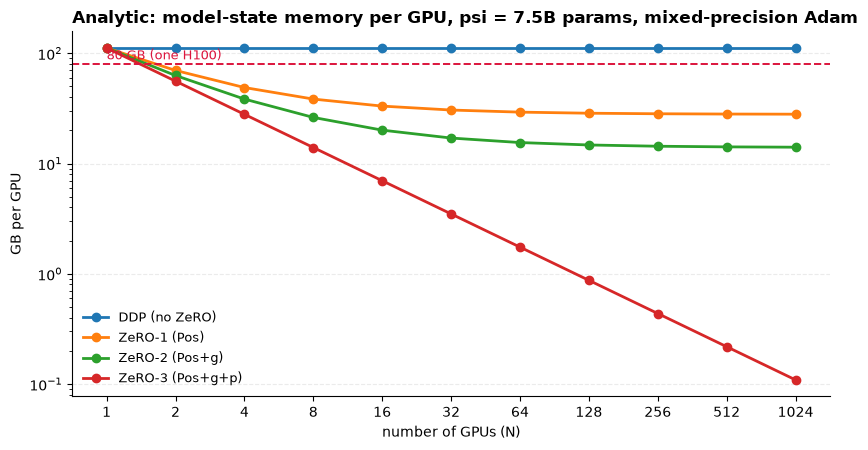

In [24]:
fig = report.fig_analytic(); plt.show()

---
## Part 12 — The cost side: when does ZeRO-3 actually hurt?

ZeRO-3's $3\Psi$ vs $2\Psi$ is only half the story. The other half is whether the extra traffic can
hide behind compute. Below I combine our measured per-step comm volume with the modelled link speed
for several interconnects.

The rule of thumb this produces is the practical one: **ZeRO-3 is nearly free on NVLink inside a node
and expensive over slow Ethernet**, which is exactly why DeepSpeed defaults to stage 2 for
comfortable-sized models and you reach for stage 3 when the model genuinely does not fit.

In [25]:
N, rows = 32, []
for k, p in PROFILES.items():
    for s, key in [("ddp","DDP (no ZeRO)"), ("zero2","ZeRO-2 (Pos+g)"), ("zero3","ZeRO-3 (Pos+g+p)")]:
        wire = results[s]["comm_bytes_per_rank_per_step"]
        hops = 2*(N-1) if s == "ddp" else (N-1)   # ring steps per collective
        rows.append(dict(link=p.name, stage=key,
                         ms=1e3*(p.latency_us*1e-6*results[s]["comm_calls_per_step"]*hops
                                 + wire/(p.bandwidth_GBps*1e9))))
t = pd.DataFrame(rows).pivot(index="link", columns="stage", values="ms")
t["ZeRO-3 / DDP"] = (t["ZeRO-3 (Pos+g+p)"]/t["DDP (no ZeRO)"]).round(2)
print("modelled communication time per step (ms), our 0.93M-param model on 32 ranks:\n")
print(t.round(3).to_string())
print("\nThe 1.50x is exact in BOTH terms and that is not a coincidence: ZeRO-3 sends 1.5x")
print("the bytes and pays 1.5x the latency hops (18 calls x (N-1) vs 6 calls x 2(N-1)).")
print("ZeRO-2 is free in time as well as in volume.")

modelled communication time per step (ms), our 0.93M-param model on 32 ranks:

stage                             DDP (no ZeRO)  ZeRO-2 (Pos+g)  ZeRO-3 (Pos+g+p)  ZeRO-3 / DDP
link                                                                                           
100 Gb Ethernet                          15.456          15.456            23.184           1.5
InfiniBand NDR 400 Gb/s                   2.004           2.004             3.006           1.5
NVLink-4 / NVSwitch (intra-node)          0.768           0.768             1.152           1.5
PCIe 4.0 x16                              3.264           3.264             4.896           1.5

The 1.50x is exact in BOTH terms and that is not a coincidence: ZeRO-3 sends 1.5x
the bytes and pays 1.5x the latency hops (18 calls x (N-1) vs 6 calls x 2(N-1)).
ZeRO-2 is free in time as well as in volume.


---
## What I take away from building this

1. **75% of training memory is the optimizer, not the model.** Every intuition about "the model is
   too big" should really be "the *training state* is too big", and mostly that means Adam.

2. **ZeRO-1 and ZeRO-2 are free.** Not cheap — free. Their communication volume is *identical* to
   DDP's, because a ring all-reduce already is a reduce-scatter followed by an all-gather; ZeRO just
   declines to throw away the partitioning in between. I did not really believe this until I measured
   both at 1.938 ψ.

3. **Stage 2 is a statement about *timing*, not about *what* you send.** Same collective, same bytes,
   issued per-layer during backward rather than once at the end. That timing change is worth 4
   bytes/param, and it is the reason bucket size is a tunable in every real implementation.

4. **Only stage 3 changes the forward pass, and only stage 3 costs you anything** (1.5× traffic, plus
   recompute). Its payoff is qualitative rather than quantitative: peak parameter memory becomes "the
   largest layer" instead of "the model", which is what removes the ceiling entirely.

5. **None of it changes the maths -- and the three ZeRO stages are bit-identical to each other.**
   That was the most satisfying measurement here: the only differences anywhere in the experiment are
   floating-point summation order.

6. **The idealised formulas lie a little, and the gap is the interesting part.** ZeRO-3's measured
   floor was 1.17 MB rather than the predicted 0.44 MB, entirely because of the one-bucket transient.
   Reproducing a formula teaches you less than finding out where it stops holding.

7. **Measure the confound before quoting the headline.** ZeRO-3 gets activation checkpointing free as
   a side effect of deleting its weights. Before controlling for that (Part 7) I would have quoted a
   number that was partly measuring something else.